In [1]:
!pip install zoofs

In [ ]:
import requests
import pandas as pd
from imblearn.over_sampling import SMOTE
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import random
import os
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss,roc_auc_score
from sklearn.ensemble import  GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from zoofs import HarrisHawkOptimization
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


**Data Collection**
**Dataset Used :** pd_speech features dataset

**Dataset Source :** UCI Machine Learning Repository

**Dataset Hosting URL :** https://archive.ics.uci.edu/dataset/470/parkinson+s+disease+classification

In [2]:
df = pd.read_csv('/content/pd_speech_features.csv')

In [3]:
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [4]:
print('Number of Features In Dataset :', df.shape[1])
print('Number of Instances In Dataset : ', df.shape[0])

Number of Features In Dataset : 755
Number of Instances In Dataset :  756


# **Data Preprocessing**
The following steps are performed on the dataset in this section:

    - Dropping Redudant Columns
    - Checking For Duplicated Rows
    - Checking For Missing Values


# Dropping The id Column

In [4]:
df.drop(['id'], axis=1, inplace=True)

In [5]:
print('Number of Features In Dataset :', df.shape[1])
print('Number of Instances In Dataset : ', df.shape[0])

Number of Features In Dataset : 754
Number of Instances In Dataset :  756


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 754 entries, gender to class
dtypes: float64(749), int64(5)
memory usage: 4.3 MB


In [8]:
df.describe()

,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,7.560000e+02,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,1.673391e-05,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,2.290134e-05,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,6.860000e-07,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,5.260000e-06,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,9.530000e-06,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,1.832500e-05,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,2.564800e-04,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


In [7]:
df['class'] = df['class'].astype('uint8')

# Checking For Duplicate Rows In Dataset

In [8]:
print('Number of Duplicated Rows :',df.duplicated().sum())

Number of Duplicated Rows : 1


In [9]:
# Remove duplicated rows
df = df.drop_duplicates()

# Optional: reset index after removing duplicates
df = df.reset_index(drop=True)

print("New Shape:", df.shape)
print("Number of Duplicated Rows :", df.duplicated().sum())

New Shape: (755, 754)
Number of Duplicated Rows : 0


# Checking For Missing Values In Dataset

In [10]:
df.isna().sum()

,0
gender,0
PPE,0
DFA,0
RPDE,0
numPulses,0
...,...
tqwt_kurtosisValue_dec_33,0
tqwt_kurtosisValue_dec_34,0
tqwt_kurtosisValue_dec_35,0
tqwt_kurtosisValue_dec_36,0


# Extracting Features Into Features & Target

In [11]:


X = df.drop(['class'], axis=1)
y = df['class']

print('Feature (X) Shape Before Balancing :', X.shape)
print('Target (y) Shape Before Balancing :', y.shape)



Feature (X) Shape Before Balancing : (755, 753)
Target (y) Shape Before Balancing : (755,)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Columns: 754 entries, gender to class
dtypes: float64(749), int64(4), uint8(1)
memory usage: 4.3 MB


# Exploratry Data Analysis
## Balance of Data

<Axes: xlabel='class', ylabel='count'>

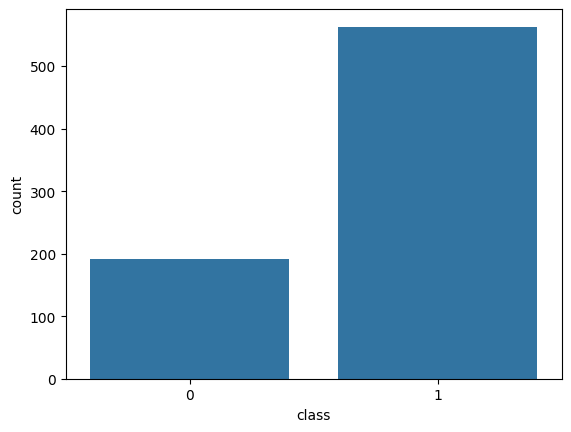

In [89]:
sns.countplot(x='class',data=df)


# Exploring Imabalance In Dataset

In [67]:
df['class'].value_counts()

,count
class,
1,563
0,192


# Split data into X & Y

In [13]:
X = df.drop(['class'], axis=1)
y = df['class']
print('Feature (X) Shape Before Balancing :', X.shape)
print('Target (y) Shape Before Balancing :', y.shape)

Feature (X) Shape Before Balancing : (755, 753)
Target (y) Shape Before Balancing : (755,)


# Scaling features between -1 and 1  for mormalization

In [ ]:
scaler = MinMaxScaler((-1,1))
X_features = scaler.fit_transform(X)

# Resampling Data

In [14]:
sm = SMOTE(random_state=300)
X, y = sm.fit_resample(X_features, y)

In [15]:
print('Feature (X) Shape After Balancing :', X.shape)
print('Target (y) Shape After Balancing :', y.shape)

Feature (X) Shape After Balancing : (1126, 753)
Target (y) Shape After Balancing : (1126,)


# splitting the dataset

In [17]:
X_train_temp , X_test , y_train_temp , y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
   X_train_temp, y_train_temp,
    test_size=0.15,
    random_state=SEED,
)


# GSA

In [50]:
TOTAL_FEATURES = X_train.shape[1]
def fitness_function(model, X_train_subset, y_train_subset, X_val_subset, y_val_subset):
    if X_train_subset.shape[1] == 0:
        return 1e10

    try:
        # Use the passed model
        model.fit(X_train_subset, y_train_subset)

        preds_prob = model.predict_proba(X_val_subset)
        preds = np.argmax(preds_prob, axis=1)

        error_acc = 1.0 - accuracy_score(y_val_subset, preds)

        logloss = log_loss(y_val_subset, preds_prob)
        error_unc = logloss / (logloss + 1.0)

        cm = confusion_matrix(y_val_subset, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        error_fnr = fn / (fn + tp + 1e-10)
        
        # Calculate feature reduction penalty based on the subset shape
        error_feat = X_train_subset.shape[1] / TOTAL_FEATURES

        fitness_score = (
            np.exp(error_acc) +
            np.exp(error_fnr) +
            np.exp(error_unc) +
            np.exp(error_feat)
        )

        return fitness_score

    except Exception as e:
        return 1e10

algo =  HarrisHawkOptimization(
    objective_function=fitness_function,
    n_iteration=30,
    population_size=20,
    minimize=True
)

base_model=LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED)
best_mask = algo.fit(
    base_model,
    X_train,
    y_train,
    X_val,
    y_val,
    verbose=True
)


# ML Models

In [ ]:


# SPECIFICITY FUNCTION

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp + 1e-10)

# FEATURE SELECTION OUTPUT
selected_idx = np.where(np.array(best_mask).astype(bool))[0]
print("\n==============================")
print(f"Optimization Done! Features Selected: {len(selected_idx)} / {X_train.shape[1]}")
print("==============================")

X_train_sel = X_train.iloc[:, selected_idx]
X_test_sel  = X_test.iloc[:, selected_idx]
# Specificity Function
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp + 1e-10)



# Models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network": Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            learning_rate='adaptive',
            max_iter=2000,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# Training + Evaluation
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_sel, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_sel)
    y_test_pred = model.predict(X_test_sel)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Generalization gap
    generalization_gap = train_acc - test_acc

    # ROC-AUC (safe for binary classification)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    roc = roc_auc_score(y_test, y_prob)

    # F1-score, Precision, and Recall
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')

    # Specificity
    spec = specificity_score(y_test, y_test_pred)

    # Store results
    results.append((
        name,
        train_acc,
        test_acc,
        generalization_gap,
        f1,
        precision,  
        recall,     
        roc,
        spec
    ))

    # Print results
    print("\n======================")
    print(name)
    print(f"Train Accuracy      : {train_acc:.4f}")
    print(f"Test Accuracy       : {test_acc:.4f}")
    print(f"Generalization Gap  : {generalization_gap:.4f}")
    print(f"F1-score            : {f1:.4f}")
    print(f"Precision           : {precision:.4f}")
    print(f"Recall              : {recall:.4f}")
    print(f"ROC-AUC             : {roc:.4f}")
    print(f"Specificity         : {spec:.4f}")



# Summary
print("\n=========== SUMMARY ===========")

for r in results:
    print(
        f"{r[0]:<20} -> "
        f"Train Acc: {r[1]:.4f}, "
        f"Test Acc: {r[2]:.4f}, "
        f"Gap: {r[3]:.4f}, "
        f"F1: {r[4]:.4f}, "
        f"Prec: {r[5]:.4f}, "
        f"Rec: {r[6]:.4f}, "
        f"ROC-AUC: {r[7]:.4f}, "
        f"Spec: {r[8]:.4f}"
    )